In [ ]:
import torch 
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import pysindy as ps
import pickle
from sklearn.inspection import PartialDependenceDisplay
from torchmetrics.regression import R2Score
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
class NN(nn.Module):
    def __init__(self, latent_dims, n_features, nodes_per_layer=16):
        nn.Module.__init__(self)
        
        self.latent_dims = latent_dims
        self.n_features = n_features
        self.n_features_in = self.latent_dims + self.n_features
        self.n_features_out = latent_dims
        self.nodes_per_layer = nodes_per_layer
        self.model_name = 'NNbase'
        self.X, self.Y = None, None
        self.X_test, self.Y_test = None, None

        self.neural_net = nn.Sequential(
            nn.Linear(self.n_features_in, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.n_features_out)
        )

        self.R2 = []
        self.train_loss = []
        self.test_loss = []
    
    def forward(self, x):
        return self.neural_net(x)

In [3]:
# Load the pre-trained model
path = 'networks/NN_ODE/ConvNN+AE+D/20251215092753_n_features=3trunc_latent_dims=3_past_timesteps=20_global_ocean_land_rp=False_tp=20_wd=0.0.pt'
latent_dims = 3
n_features = 3
x_inds = [1, 2, 3, -3, -2, -1] 
model = NN(latent_dims=latent_dims, n_features=n_features)
model.load_state_dict(torch.load(path, map_location=device, weights_only=True))

<All keys matched successfully>

In [4]:
# Load data
XZ_train = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5, 6]_latent_dims=3_past_timesteps=20/20251215092753_global_ocean_land_rp=False_eps=1.0_Ztrain_ConvNN+AE+D_tp=20_wd=0.0.npy')
XZ_train = XZ_train[:, :, x_inds]
XZ_val = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5, 6]_latent_dims=3_past_timesteps=20/20251215092753_global_ocean_land_rp=False_eps=1.0_Zval_ConvNN+AE+D_tp=20_wd=0.0.npy')
XZ_val = XZ_val[:, :, x_inds]

# Compute derivates
def get_derivative(XZ, first_Z_ind):
    dm = ps.FiniteDifference()
    # dm = ps.SmoothedFiniteDifference(smoother_kws={'window_length': 10})
    dZdt = np.array([dm._differentiate(Z[:, first_Z_ind:], t=1) for Z in XZ])
    dZdt = torch.tensor(dZdt, dtype=torch.float32)
    return dZdt

dZdt_train = get_derivative(XZ_train, first_Z_ind=-latent_dims)
dZdt_test = get_derivative(XZ_val, first_Z_ind=-latent_dims)
# model.X = torch.tensor(XZ_train[:,:, x_inds], dtype=torch.float32, device=device)
# model.X_test = torch.tensor(XZ_val[:,:, x_inds], dtype=torch.float32, device=device)
# model.Y = dZdt_train.to(device)
# model.Y_test = dZdt_test.to(device)

In [15]:
# Sklearn wrapper for PyTorch model
class PyTorchWrapper:
    # Add this line to tell sklearn it's a regressor
    _estimator_type = "regressor"
    def __init__(self, model, device='cpu'):
        self.model = model.to(device)
        self.model.eval()
        self.device = device
        
    # Sklearn expects a fit method, even if it does nothing
    def __sklearn_is_fitted__(self):
        return True

    def fit(self, X, y=None):
        return self
    
    def predict(self, X):
        # Convert input to tensor
        X = torch.tensor(X, dtype=torch.float32, device=self.device)
        with torch.no_grad():
            outputs = self.model(X)
        # Convert back to numpy
        return outputs.cpu().numpy()

class PySINDyWrapper:
    # Add this line to tell sklearn it's a regressor
    _estimator_type = "regressor"
    def __init__(self, model, latent_dims, n_features):
        self.model = model
        self.latent_dims = latent_dims
        self.n_features = n_features
        # self.Xi = self.model.coefficients().T
        # self.pysindy_order = [-3, -2, -1, 0, 1, 2]
    
    # Sklearn expects a fit method, even if it does nothing
    def __sklearn_is_fitted__(self):
        return True

    def fit(self, X, y=None):
        return self
    
    def predict(self, X):
        # X is of shape (n_samples, n_features)
        # Theta = self.model.feature_library.transform(X[:, self.pysindy_order])  # works too but slower
        # return Theta @ self.Xi
        z = X[:, -self.latent_dims:]
        x = X[:, :self.n_features]
        return self.model.predict(x=z, u=x)

In [7]:
with open('SINDy_ODEs/equations/model_20251215092753_latent_dims=3_tp=20_degree=3_lambda=0.00034.pkl', 'rb') as f:
    model_ODE = pickle.load(f)

Generating PDPs for Output 0...
Generating PDPs for Output 1...
Generating PDPs for Output 2...


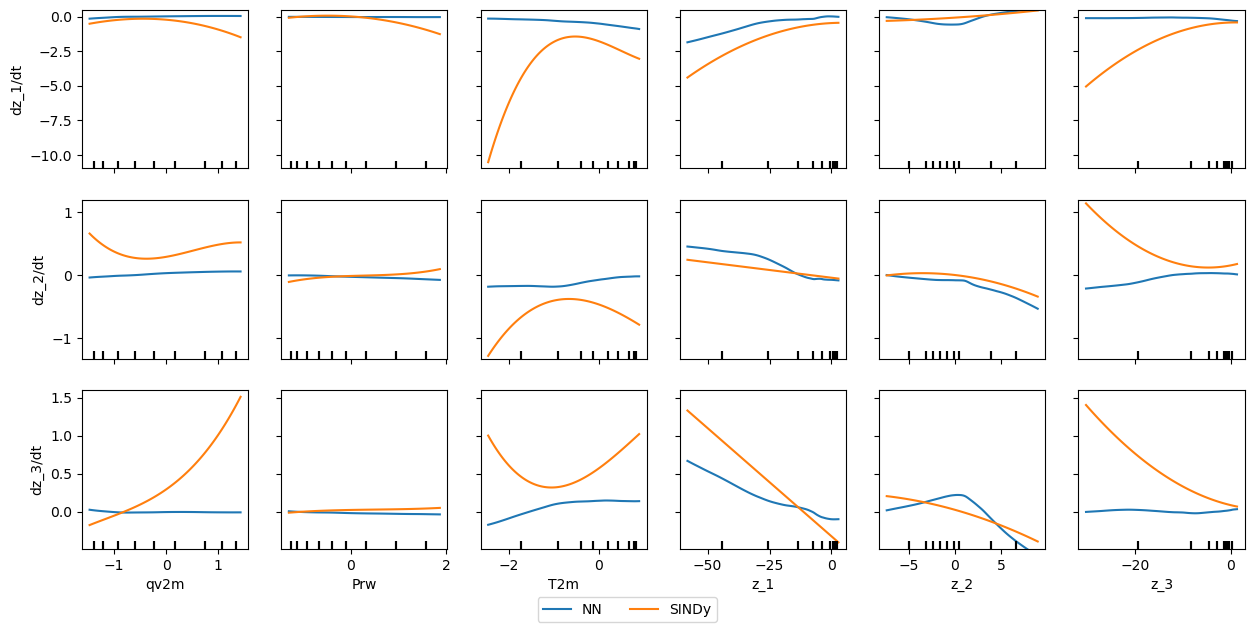

In [52]:
# Initialize wrapper
nn_model = PyTorchWrapper(model, device=device)
sindy_model = PySINDyWrapper(model_ODE, latent_dims, n_features)
n_samples = 1_00
inds = np.random.choice(XZ_val.shape[0], n_samples)  # draws n_samples random coordinates
X = XZ_val[inds]
X = X.reshape(-1, latent_dims + n_features)
# Define feature names for clarity
feature_names = ['qv2m', 'Prw', 'T2m', 'z_1', 'z_2', 'z_3']
fig, axs = plt.subplots(3, 6, figsize=(15, 7), sharex='col', sharey='row')
# Plotting per output
for output_idx, ax in zip(range(3), axs):
    print(f"Generating PDPs for Output {output_idx}...")
    #fig, ax = plt.subplots(figsize=(15, 10))
    
    PartialDependenceDisplay.from_estimator(
        nn_model, 
        X,       # Your training data as a NumPy array or DataFrame
        features=range(6),  # Indices of the inputs
        feature_names=feature_names,
        target=output_idx,  # This specifies which of the 3 outputs to plot
        ax=ax,
        #kind='both',
        #ice_lines_kw={"color": "tab:blue", "alpha": 0.1}, # customize ICE look
        pd_line_kw={"color": "tab:blue", "linestyle": "-", "label": "NN"}
    )

    PartialDependenceDisplay.from_estimator(
        sindy_model, 
        X,       # Your training data as a NumPy array or DataFrame
        features=range(6),  # Indices of the inputs
        feature_names=feature_names,
        target=output_idx,  # This specifies which of the 3 outputs to plot
        ax=ax,
        #kind='both',
        #ice_lines_kw={"color": "tab:blue", "alpha": 0.1}, # customize ICE look
        pd_line_kw={"color": "tab:orange", "linestyle": "-", "label": "SINDy"}
    )
    # --- THE FIX FOR LABELS ---
    for col_idx, a in enumerate(ax):
        # 1. Handle Y-Labels: Only keep for the first column
        if col_idx == 0:
            a.set_ylabel(f"dz_{output_idx+1}/dt")
        else:
            a.set_ylabel("") # Remove sklearn's auto-generated label

        if output_idx != 2: # Assuming 3 rows total (0, 1, 2)
            a.set_xlabel("") # Remove sklearn's auto-generated label
    # print(ax)
    # plt.suptitle(f"Partial Dependence for Output {output_idx}")
    # plt.tight_layout()
    # plt.show()
[ax.get_legend().remove() for ax in axs.flatten() if ax.get_legend()]
# Plot legend below the plots
handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2)
plt.subplots_adjust(bottom=0.11)

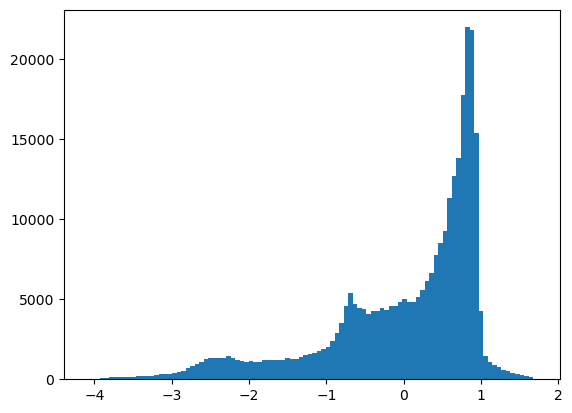

In [46]:
plt.hist(XZ_val[..., 2].flatten()[::100], bins=100);

Generating PDPs for Output 0...


Axes(0.125,0.11;0.775x0.77)


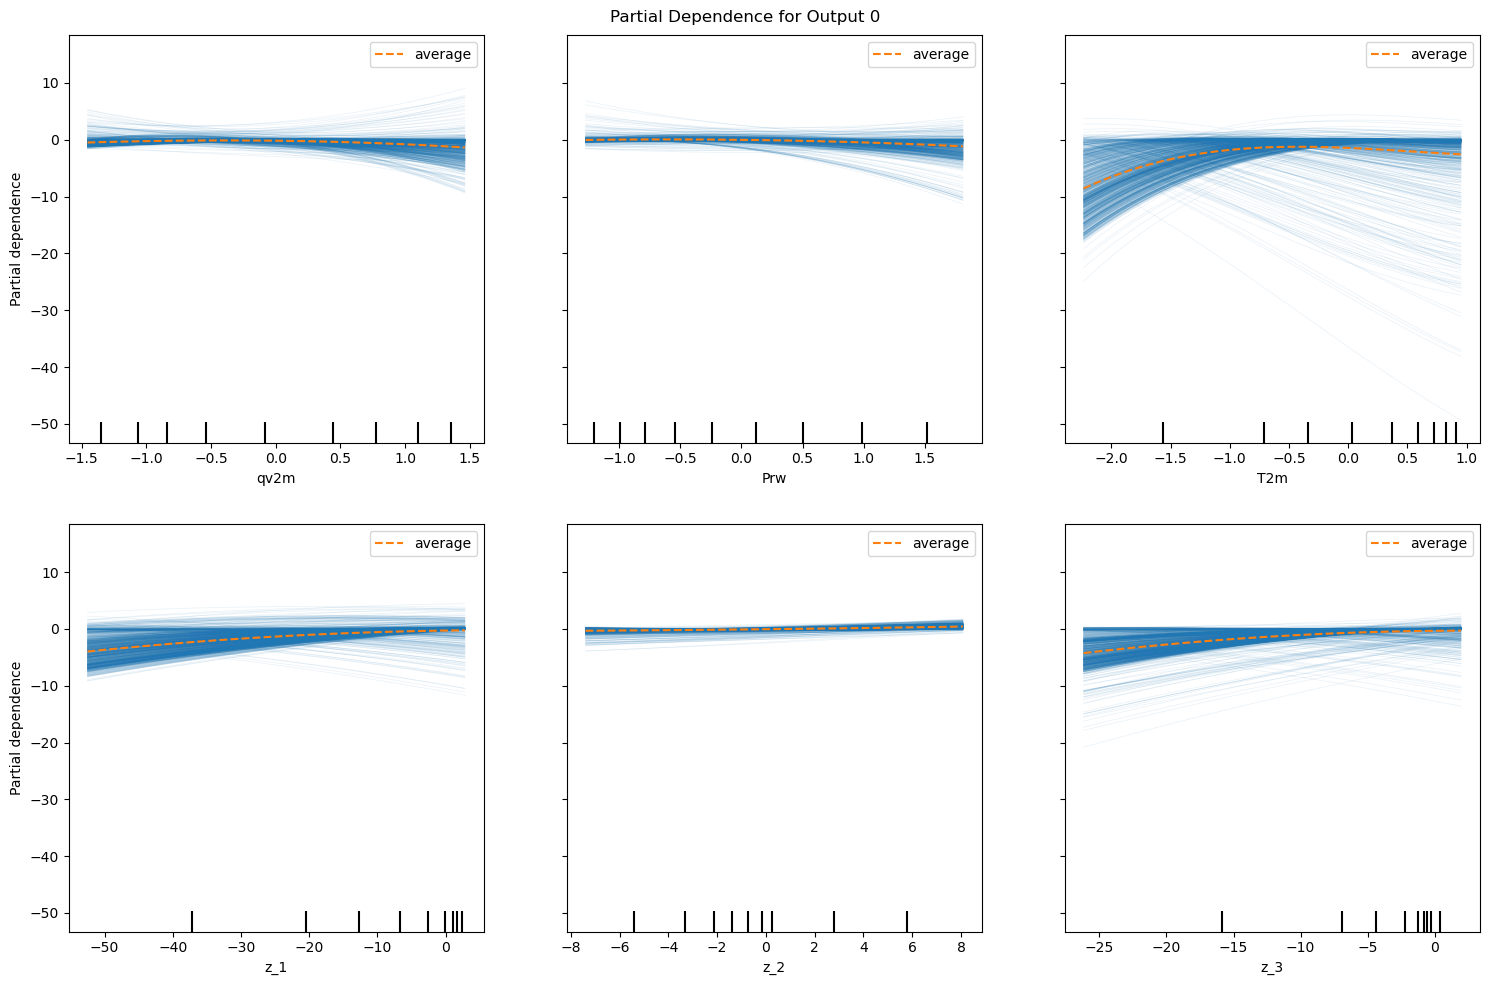

Generating PDPs for Output 1...


KeyboardInterrupt: 

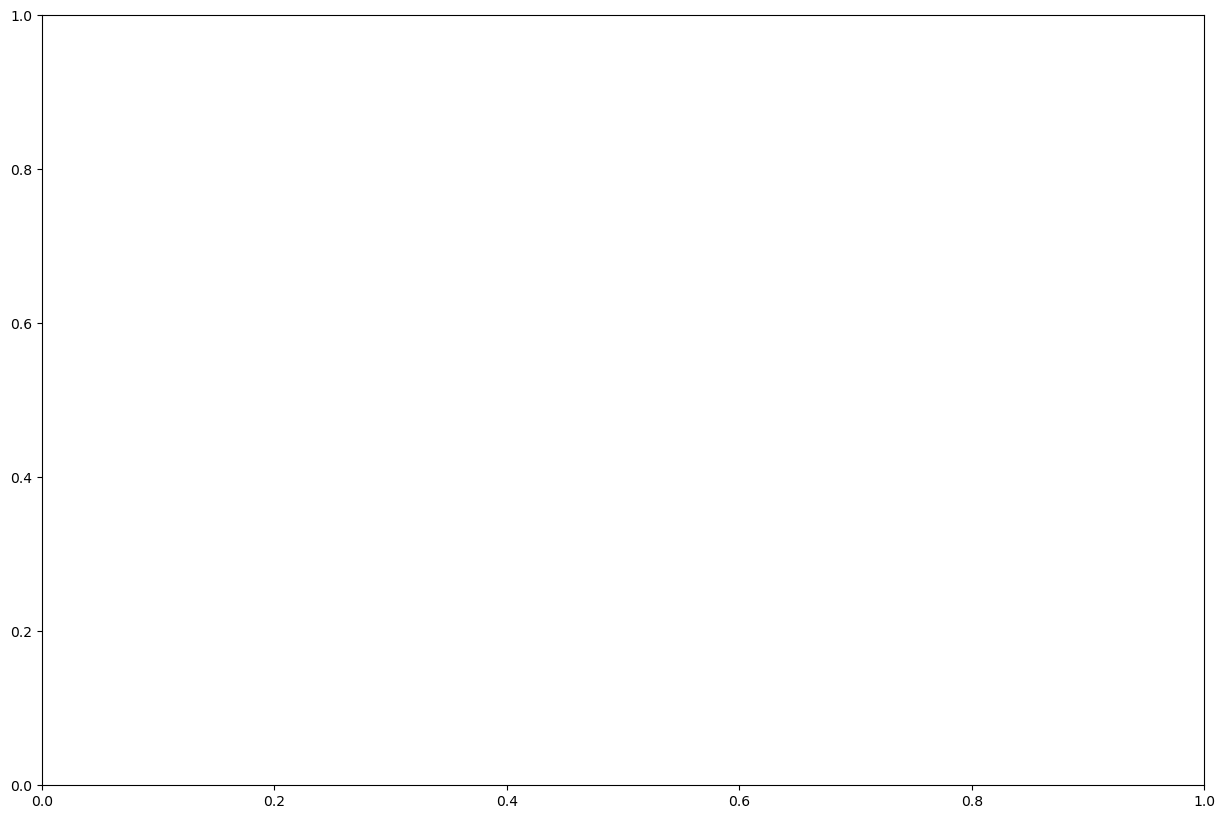

In [13]:
# Initialize wrapper
wrapped_model = PySINDyWrapper(model_ODE, latent_dims, n_features)
n_samples = 1_000
inds = np.random.choice(XZ_val.shape[0], n_samples)  # draws n_samples random coordinates
input_sindy_order = [3, 4, 5, 0, 1, 2]  # z_1, z_2, z_3, qv2m, Prw, T2m
#X = XZ_val[..., input_sindy_order]  # PySINDy model expects inputs in order (z_1, ..., z_n, x_1, ..., x_n)
X = XZ_val[inds]
# X = X[..., input_sindy_order]

X = X.reshape(-1, latent_dims + n_features)
# Define feature names for clarity
feature_names = ['qv2m', 'Prw', 'T2m', 'z_1', 'z_2', 'z_3']

# Plotting per output
for output_idx in range(3):
    print(f"Generating PDPs for Output {output_idx}...")
    fig, ax = plt.subplots(figsize=(15, 10))
    
    PartialDependenceDisplay.from_estimator(
        wrapped_model, 
        X,       # Your training data as a NumPy array or DataFrame
        features=range(6),  # Indices of the inputs
        feature_names=feature_names,
        target=output_idx,  # This specifies which of the 3 outputs to plot
        ax=ax,
        kind='both',
        ice_lines_kw={"color": "tab:blue", "alpha": 0.1}, # customize ICE look
        pd_line_kw={"color": "tab:orange", "linestyle": "--"}
    )
    print(ax)
    plt.suptitle(f"Partial Dependence for Output {output_idx}")
    plt.tight_layout()
    plt.show()

In [ ]:
# Initialize wrapper
wrapped_model = PySINDyWrapper(model_ODE)
n_samples = 1_000
inds = np.random.choice(XZ_val.shape[0], n_samples)  # draws n_samples random coordinates
X = XZ_val[inds]
X = X.reshape(-1, latent_dims + n_features)
# Define feature names for clarity
feature_names = ['qv2m', 'Prw', 'T2m', 'z_1', 'z_2', 'z_3']

# Plotting per output
for output_idx in range(3):
    print(f"Generating PDPs for Output {output_idx}...")
    fig, ax = plt.subplots(figsize=(15, 10))
    
    PartialDependenceDisplay.from_estimator(
        wrapped_model, 
        X,       # Your training data as a NumPy array or DataFrame
        features=range(6),  # Indices of the inputs
        feature_names=feature_names,
        target=output_idx,  # This specifies which of the 3 outputs to plot
        ax=ax,
        kind='both',
        ice_lines_kw={"color": "tab:blue", "alpha": 0.1}, # customize ICE look
        pd_line_kw={"color": "tab:orange", "linestyle": "--"}
    )
    print(ax)
    plt.suptitle(f"Partial Dependence for Output {output_idx}")
    plt.tight_layout()
    plt.show()

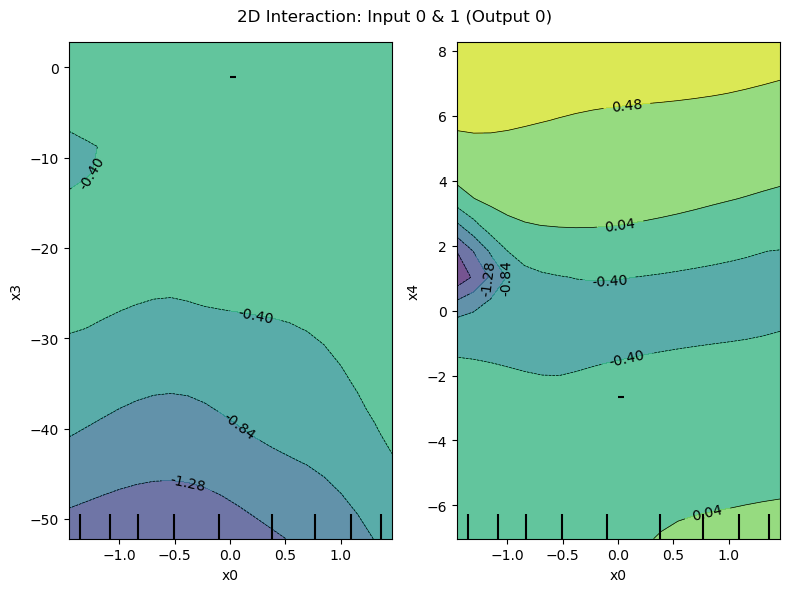

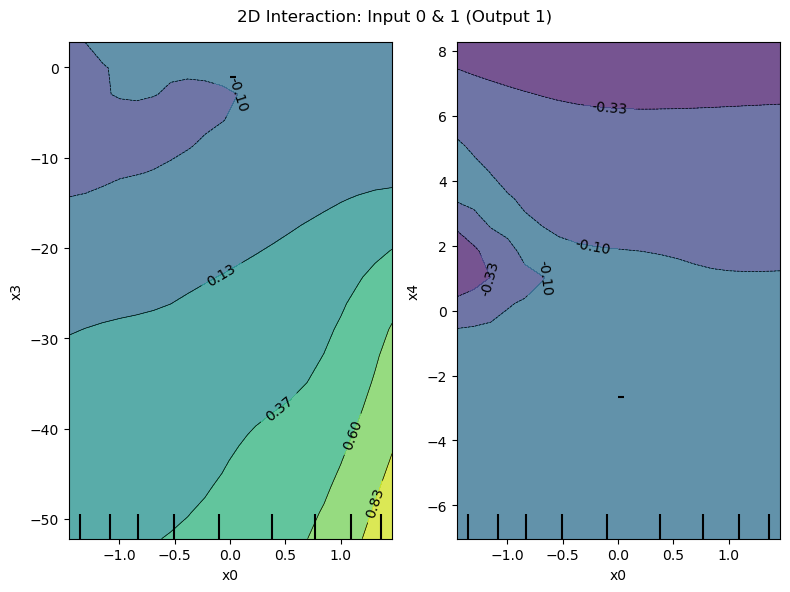

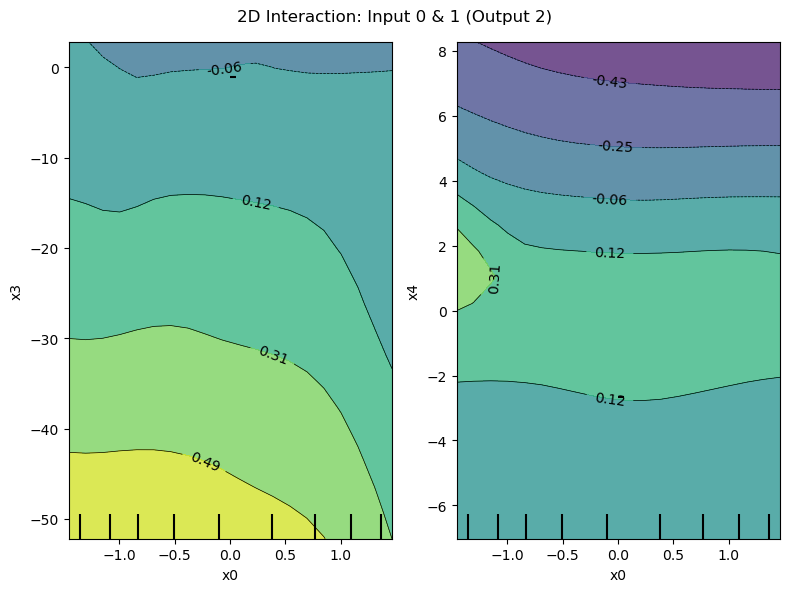

In [66]:
for output_idx in range(3):
    fig, ax = plt.subplots(figsize=(8, 6))
    
    display = PartialDependenceDisplay.from_estimator(
        wrapped_model,
        X,
        features=[(0,3), (0,4)], # Pass the tuple here
        target=output_idx,
        ax=ax,
        grid_resolution=20 # Higher resolution = smoother contours
    )
    
    plt.suptitle(f"2D Interaction: Input 0 & 1 (Output {output_idx})")
    plt.tight_layout()
    plt.show()

In [12]:
model_wrapped = PyTorchWrapper(model, device=device)

In [ ]:
n_samples = 100
inds = np.random.choice(XZ_val.shape[0], n_samples)  # draws n_samples random coordinates
X = XZ_val[inds]
X.shape

(50000, 370, 6)

In [35]:
y_pred = torch.tensor(model_wrapped.predict(X), device=device)

In [36]:
y_test = dZdt_test[inds].reshape(-1, latent_dims).to(device)

In [38]:
R2Score()(y_pred, y_test)

tensor(0.7625, device='cuda:0')